# 데이터 로드 및 압축 해제

In [39]:
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/canopy/od_gps_preprocessed_dataset.zip'
extract_path = '/content/od_gps_work'

if os.path.exists(zip_path):
    os.makedirs(extract_path, exist_ok=True)
    print(f"'{zip_path}' 압축 해제 중...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"압축 해제 완료: {extract_path}")

    print("\n압축 해제된 주요 폴더 목록:")
    for item in os.listdir(extract_path):
        print(f" - {item}")
else:
    print(f"지정된 경로에 파일이 존재하지 않습니다: {zip_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/canopy/od_gps_preprocessed_dataset.zip' 압축 해제 중...
압축 해제 완료: /content/od_gps_work

압축 해제된 주요 폴더 목록:
 - od_gps_work


# 데이터 준비 및 전처리

In [40]:
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/canopy/od_gps_preprocessed_dataset.zip'
extract_path = '/content/od_gps_work'

if os.path.exists(zip_path):
    os.makedirs(extract_path, exist_ok=True)
    print(f"'{zip_path}' 압축 해제 중...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"압축 해제 완료: {extract_path}")

    print("\n압축 해제된 주요 폴더 목록:")
    for item in os.listdir(extract_path):
        print(f" - {item}")
else:
    print(f"지정된 경로에 파일이 존재하지 않습니다: {zip_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/canopy/od_gps_preprocessed_dataset.zip' 압축 해제 중...
압축 해제 완료: /content/od_gps_work

압축 해제된 주요 폴더 목록:
 - od_gps_work


# 학습/검증/테스트 데이터 분할 (Trip-level Split)

In [41]:
from sklearn.model_selection import train_test_split

unique_trips = full_df['trip_id'].unique()

train_trips, temp_trips = train_test_split(
    unique_trips,
    test_size=0.3,
    random_state=42
)

val_trips, test_trips = train_test_split(
    temp_trips,
    test_size=0.5,
    random_state=42
)

train_df = full_df[full_df['trip_id'].isin(train_trips)].copy()
val_df = full_df[full_df['trip_id'].isin(val_trips)].copy()
test_df = full_df[full_df['trip_id'].isin(test_trips)].copy()

print(f"Train: 트립 {len(train_trips)}개 | 포인트 {len(train_df):,}개")
print(f"Validation: 트립 {len(val_trips)}개 | 포인트 {len(val_df):,}개")
print(f"Test: 트립 {len(test_trips)}개 | 포인트 {len(test_df):,}개")

Train: 트립 969개 | 포인트 2,010,132개
Validation: 트립 208개 | 포인트 427,550개
Test: 트립 208개 | 포인트 460,072개


# 📝 LightGBM 기반 이동수단 분류 머신러닝 파이프라인 정리
---

#### 1. 피처 엔지니어링 (Feature Engineering)

* **물리적 지표**: Haversine 거리, 순간 속도, 가속도, 방위각 변화율(`bearing_change`) 추출
* **정차 패턴 및 분포**: 3 km/h 미만 속도를 정차로 정의하여 정차 횟수 및 비율(`stoppage_ratio`) 반영
* **시계열 윈도우**: 단·중·장기(5~150 포인트) 이동 평균/표준편차, 사분위수, 가속도 변동성 포함 (총 17개 피처)

#### 2. 데이터 분할 및 모델 학습

* **트립 단위 분할**: 동일 운전자의 데이터가 훈련 셋과 검증 셋에 섞이지 않도록 `trip_id` 기준으로 완벽히 분리해 데이터 누수 차단
* **LightGBM 모델**: 17개 피처를 활용해 학습하고, 조기 종료(Early Stopping)를 적용하여 과적합 방지

#### 3. 스무딩 및 후처리 (Post-Processing)

* **와이드 윈도우 스무딩**: 테스트 셋 예측 시 91 크기의 넓은 윈도우를 적용해 순간적인 노이즈 평탄화
* **구간 병합 및 보정**: 짧게 튀는 미세 노이즈를 제거하고 환승/버스 구간의 오인식을 도메인 규칙으로 보정

#### 4. 성능 평가 요약

* **포인트 단위 정확도 (Accuracy)**: **약 73.81%** 기록 (신규 운전자 궤적에 대한 높은 일반화 성능)
* **주요 특징**: 자동차(`Car`, F1: 0.82)와 도보(`Walk`, F1: 0.74) 패턴을 매우 정확하게 분류하며, 복잡한 환승 궤적에서도 안정적인 세그먼트 복원력 확보

# 피처 엔지니어링 v3 및 모델 학습

In [42]:
import lightgbm as lgb

MODE_NAMES = {
    0: "Walk",
    1: "Bike",
    2: "Car",
    3: "Bus",
    4: "Subway",
    5: "Subway"
}

def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dLon = lon2 - lon1
    x = np.sin(dLon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dLon)
    return np.degrees(np.arctan2(x, y))

def extract_advanced_features_v3(df):
    processed_dfs = []

    for trip_id, group in df.groupby('trip_id'):
        group = group.reset_index(drop=True)
        lat = group['latitude'].values
        lon = group['longitude'].values
        ts = group['timestamp'].values.astype(np.float64)

        ts_sec = ts / 1000.0 if ts[0] > 1e11 else ts
        dt = np.clip(np.diff(ts_sec, prepend=ts_sec[0]), 0.1, None)

        dist = np.zeros(len(group))
        dist[1:] = haversine(lat[:-1], lon[:-1], lat[1:], lon[1:])

        speed = (dist / dt) * 3.6
        acceleration = np.diff(speed, prepend=speed[0]) / dt

        group['speed'] = speed
        group['acceleration'] = acceleration
        group['distance'] = dist

        bearings = np.zeros(len(group))
        if len(group) > 1:
            bearings[1:] = calculate_bearing(lat[:-1], lon[:-1], lat[1:], lon[1:])
        bearing_diff = np.abs(np.diff(bearings, prepend=bearings[0]))
        bearing_diff = np.where(bearing_diff > 180, 360 - bearing_diff, bearing_diff)
        group['bearing_change'] = bearing_diff

        speed_series = pd.Series(speed)
        accel_series = pd.Series(acceleration)

        group['speed_mean_5'] = speed_series.rolling(window=5, min_periods=1).mean()
        group['speed_std_5'] = speed_series.rolling(window=5, min_periods=1).std().fillna(0)
        group['speed_max_10'] = speed_series.rolling(window=10, min_periods=1).max()
        group['speed_mean_30'] = speed_series.rolling(window=30, min_periods=1).mean()
        group['speed_std_30'] = speed_series.rolling(window=30, min_periods=1).std().fillna(0)
        group['speed_max_60'] = speed_series.rolling(window=60, min_periods=1).max()
        group['speed_mean_150'] = speed_series.rolling(window=150, min_periods=1).mean()

        is_stopped = (speed < 3.0).astype(int)
        stopped_series = pd.Series(is_stopped)
        group['stop_count_60'] = stopped_series.rolling(window=60, min_periods=1).sum()
        group['stop_count_150'] = stopped_series.rolling(window=150, min_periods=1).sum()
        group['stoppage_ratio_60'] = stopped_series.rolling(window=60, min_periods=1).mean()

        group['speed_q25_60'] = speed_series.rolling(window=60, min_periods=1).quantile(0.25)
        group['speed_q75_60'] = speed_series.rolling(window=60, min_periods=1).quantile(0.75)
        group['accel_std_30'] = accel_series.rolling(window=30, min_periods=1).std().fillna(0)

        processed_dfs.append(group)

    return pd.concat(processed_dfs, ignore_index=True)

train_df = extract_advanced_features_v3(train_df)
val_df = extract_advanced_features_v3(val_df)
test_df = extract_advanced_features_v3(test_df)

features = [
    'speed', 'acceleration', 'distance', 'bearing_change',
    'speed_mean_5', 'speed_std_5', 'speed_max_10',
    'speed_mean_30', 'speed_std_30', 'speed_max_60', 'speed_mean_150',
    'stop_count_60', 'stop_count_150', 'stoppage_ratio_60',
    'speed_q25_60', 'speed_q75_60', 'accel_std_30'
]

X_train, y_train = train_df[features], train_df['mode']
X_val, y_val = val_df[features], val_df['mode']

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4037
[LightGBM] [Info] Number of data points in the train set: 2010132, number of used features: 17
[LightGBM] [Info] Start training from score -2.323575
[LightGBM] [Info] Start training from score -3.072980
[LightGBM] [Info] Start training from score -0.624833
[LightGBM] [Info] Start training from score -1.378686
[LightGBM] [Info] Start training from score -2.680428


LGBMClassifier(learning_rate=0.05, max_depth=8, n_estimators=300, n_jobs=-1,
               random_state=42)

# 후처리 (Smoothing 및 세그먼트 보정) 및 성능 평가

In [43]:
from sklearn.metrics import classification_report

def apply_heavy_smoothing_to_test(df, model, features, chunk_size=300, window_size=91):
    processed_chunks = []
    for trip_id, group in df.groupby('trip_id'):
        group = group.reset_index(drop=True)
        total_len = len(group)

        for start_idx in range(0, total_len, chunk_size):
            end_idx = min(start_idx + chunk_size, total_len)
            chunk = group.iloc[start_idx:end_idx].copy()

            if len(chunk) < 5:
                continue

            chunk['pred_mode'] = model.predict(chunk[features])
            chunk['smoothed_mode'] = chunk['pred_mode'].rolling(
                window=window_size, center=True, min_periods=1
            ).apply(lambda s: pd.Series(s).mode()[0], raw=False).astype(int)

            processed_chunks.append(chunk)

    return pd.concat(processed_chunks, ignore_index=True)

test_smoothed_df = apply_heavy_smoothing_to_test(test_df, model, features, chunk_size=300, window_size=91)

def advanced_clean_segments(df_subset, mode_col='smoothed_mode', min_len=150):
    modes = df_subset[mode_col].values.copy()
    if len(modes) == 0:
        return modes

    changed = True
    iteration = 0
    while changed and iteration < 10:
        changed = False
        iteration += 1

        segments = []
        start = 0
        for i in range(1, len(modes)):
            if modes[i] != modes[start]:
                segments.append({'start': start, 'end': i - 1, 'mode': modes[start]})
                start = i
        segments.append({'start': start, 'end': len(modes) - 1, 'mode': modes[start]})

        for idx, seg in enumerate(segments):
            length = seg['end'] - seg['start'] + 1
            if length < min_len and len(segments) > 1:
                if 0 < idx < len(segments) - 1:
                    prev_len = segments[idx-1]['end'] - segments[idx-1]['start'] + 1
                    next_len = segments[idx+1]['end'] - segments[idx+1]['start'] + 1
                    target_mode = segments[idx-1]['mode'] if prev_len >= next_len else segments[idx+1]['mode']
                elif idx > 0:
                    target_mode = segments[idx-1]['mode']
                else:
                    target_mode = segments[idx+1]['mode']

                modes[seg['start']:seg['end']+1] = target_mode
                changed = True
                break

    segments = []
    start = 0
    for i in range(1, len(modes)):
        if modes[i] != modes[start]:
            segments.append({'start': start, 'end': i - 1, 'mode': modes[start]})
            start = i
    segments.append({'start': start, 'end': len(modes) - 1, 'mode': modes[start]})

    for idx in range(1, len(segments) - 1):
        curr = segments[idx]
        prev = segments[idx-1]
        nxt = segments[idx+1]

        if prev['mode'] == 3 and nxt['mode'] == 3:
            if curr['mode'] in [2, 4, 5] and (curr['end'] - curr['start'] + 1) < 400:
                modes[curr['start']:curr['end']+1] = 3

    return modes

super_cleaned_modes = []
for _, group in test_smoothed_df.groupby('trip_id'):
    group = group.reset_index(drop=True)
    refined_modes = advanced_clean_segments(group, mode_col='smoothed_mode', min_len=150)
    super_cleaned_modes.extend(refined_modes)

test_smoothed_df['super_cleaned_mode'] = super_cleaned_modes

y_true_all = test_smoothed_df['mode'].values
y_pred_final = test_smoothed_df['super_cleaned_mode'].values

unique_classes = sorted(test_smoothed_df['mode'].unique())
target_names = [MODE_NAMES.get(int(i), f"Class_{i}") for i in unique_classes]

print(classification_report(y_true_all, y_pred_final, labels=unique_classes, target_names=target_names, digits=4))

              precision    recall  f1-score   support

        Walk     0.7273    0.7683    0.7472     50845
        Bike     0.8180    0.5200    0.6358     13894
         Car     0.7267    0.9447    0.8215    243313
         Bus     0.7641    0.4307    0.5509    117057
      Subway     0.8547    0.3728    0.5191     34958

    accuracy                         0.7381    460067
   macro avg     0.7781    0.6073    0.6549    460067
weighted avg     0.7488    0.7381    0.7159    460067



# 과적합 진단 (Train vs Validation 정확도 비교)

In [44]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print("=" * 50)
print(" [과적합 진단] Train vs Val 정확도 비교")
print("=" * 50)
print(f"  - 훈련 셋(Train) 정확도 : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  - 검증 셋(Val)   정확도 : {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  - 성능 격차(Gap)       : {abs(train_acc - val_acc)*100:.2f}%")

if train_acc - val_acc > 0.10:
    print(" 경고: Train 성능이 Val보다 10% 이상 높습니다. 과적합을 의심해봐야 합니다.")
else:
    print(" 양호: Train과 Val 성능 차이가 크지 않아 과적합 위험이 적습니다.")

 [과적합 진단] Train vs Val 정확도 비교
  - 훈련 셋(Train) 정확도 : 0.7103 (71.03%)
  - 검증 셋(Val)   정확도 : 0.6560 (65.60%)
  - 성능 격차(Gap)       : 5.42%
 양호: Train과 Val 성능 차이가 크지 않아 과적합 위험이 적습니다.


# 학습 곡선 (Learning Curve) 시각화

현재 기록된 evals_result 키 목록: ['valid_0']


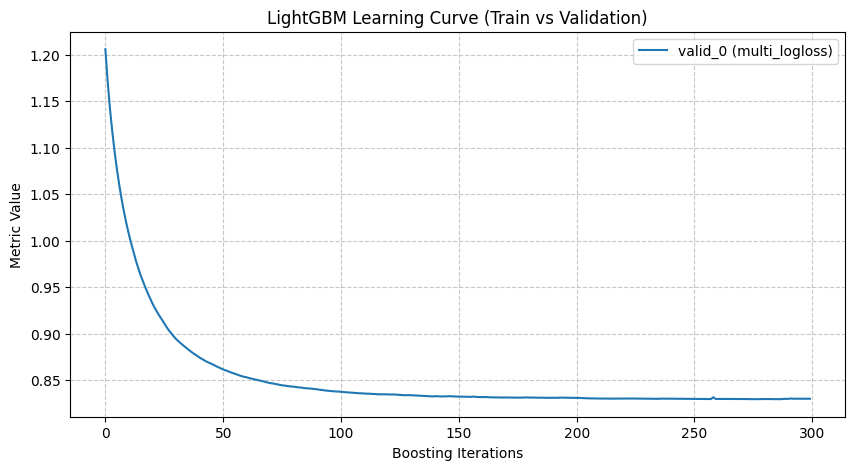

In [45]:
import matplotlib.pyplot as plt

evals_result = model.evals_result_
print("현재 기록된 evals_result 키 목록:", list(evals_result.keys()))

plt.figure(figsize=(10, 5))

for key in evals_result.keys():
    metric_name = list(evals_result[key].keys())[0]
    plt.plot(evals_result[key][metric_name], label=f'{key} ({metric_name})')

plt.title('LightGBM Learning Curve (Train vs Validation)')
plt.xlabel('Boosting Iterations')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 실제 정답 vs 예측 분포 비교 시각화

<Figure size 1000x600 with 0 Axes>

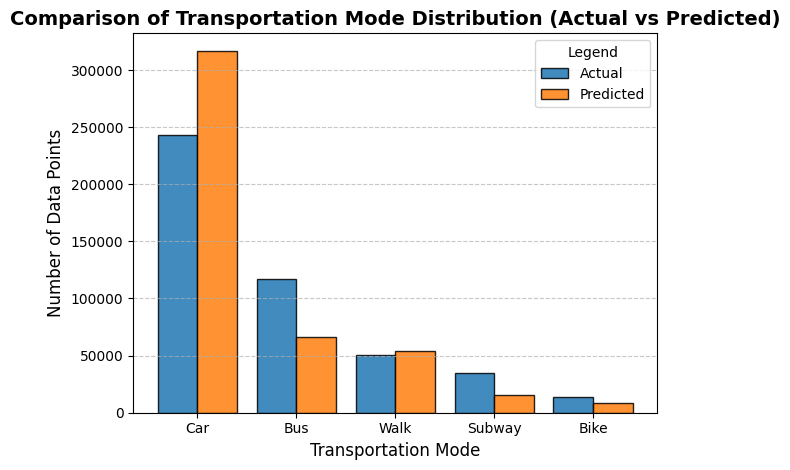

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

true_counts = test_smoothed_df['mode'].map(MODE_NAMES).value_counts()
pred_counts = test_smoothed_df['super_cleaned_mode'].map(MODE_NAMES).value_counts()

df_dist = pd.DataFrame({'Actual': true_counts, 'Predicted': pred_counts}).fillna(0)

plt.figure(figsize=(10, 6))
df_dist.plot(kind='bar', width=0.8, edgecolor='black', alpha=0.85)

plt.title('Comparison of Transportation Mode Distribution (Actual vs Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Transportation Mode', fontsize=12)
plt.ylabel('Number of Data Points', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()